In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_parquet("../datasets/business_SB.parquet").copy()
df = df[df["is_open"] == 1]
df["popularity"] = df["stars"] * np.log1p(df["review_count"])

Text(0.5, 1.0, 'Popularity Boxplot')

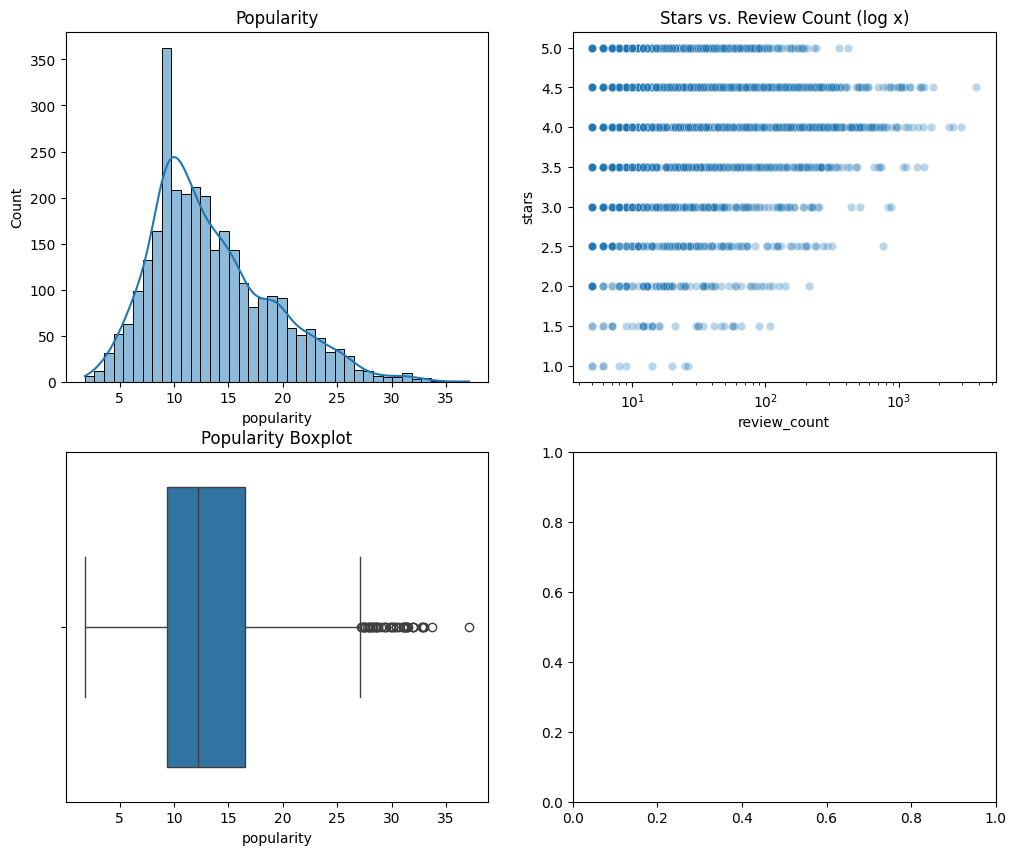

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df["popularity"], bins=40, kde=True, ax=axes[0,0])
axes[0,0].set_title("Popularity")

sns.scatterplot(data=df, x="review_count", y="stars", alpha=0.3, ax=axes[0,1])
axes[0,1].set_xscale("log")
axes[0,1].set_title("Stars vs. Review Count (log x)")

sns.boxplot(x=df["popularity"], ax=axes[1,0])
axes[1,0].set_title("Popularity Boxplot")

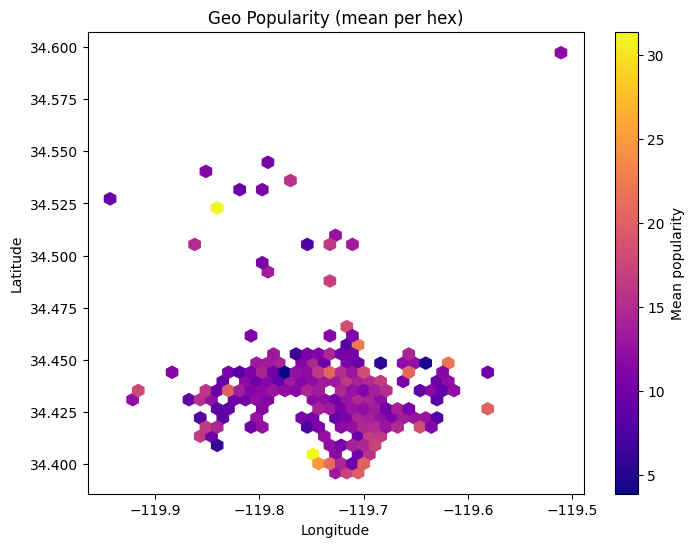

In [8]:
df_geo = df.dropna(subset=["latitude","longitude"])
plt.figure(figsize=(8,6))
hb = plt.hexbin(df_geo["longitude"], df_geo["latitude"],
                C=df_geo["popularity"], gridsize=40, reduce_C_function=np.mean,
                cmap="plasma")
plt.colorbar(hb, label="Mean popularity")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title("Geo Popularity (mean per hex)")
plt.show()


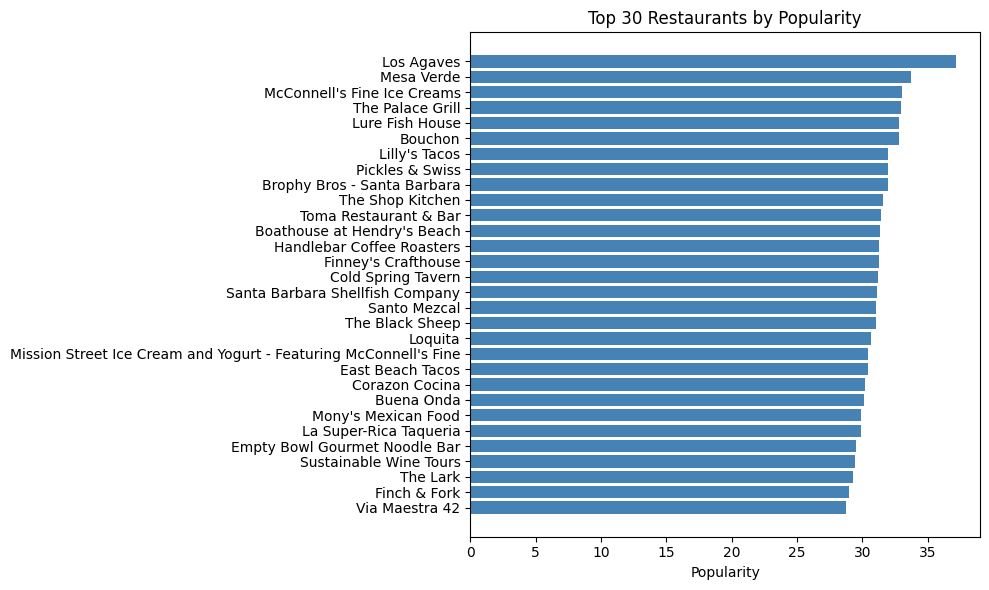

In [9]:
top = df.nlargest(30, "popularity")  # pick N you like
plt.figure(figsize=(10,6))
plt.barh(top["name"], top["popularity"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Popularity"); plt.title("Top 30 Restaurants by Popularity")
plt.tight_layout(); plt.show()